<a href="https://colab.research.google.com/github/admvitorramos/fundamentos-ml/blob/main/fundamentos_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# Importando bibliotecas para manipulação de dados e visualização
import numpy as np
import matplotlib.pyplot as plt

# Importando geradores de dados do scikit-learn
from sklearn.datasets import make_classification, make_regression, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

# Configuração de estilo para os gráficos
plt.style.use('ggplot')

Classificação Binária
- A classificação binária é a tarefa de prever se uma instância pertence à classe A ou à classe B (ex: 0 ou 1, spam ou não-spam).


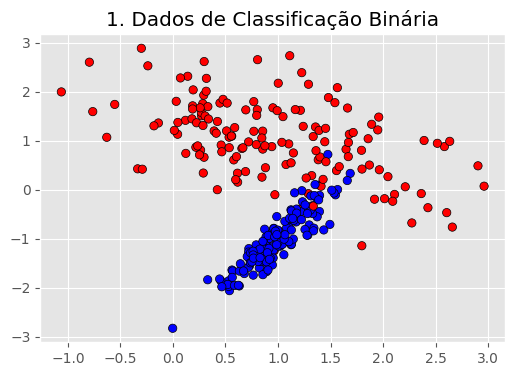

In [20]:
# Gerando dados sintéticos para Classificação Binária
X_clf, y_clf = make_classification(n_samples=300, n_features=2, n_informative=2,
                                   n_redundant=0, n_clusters_per_class=1, random_state=42)

# Dividindo em treino (80%) e teste (20%)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, cmap='bwr', edgecolors='k')
plt.title("1. Dados de Classificação Binária")
plt.show()

Regressão Logística
- Apesar do nome, a Regressão Logística é um algoritmo de classificação. Ela estima a probabilidade de uma instância pertencer a uma determinada classe.

In [21]:
from sklearn.linear_model import LogisticRegression

# Inicializando e treinando o modelo
log_reg = LogisticRegression()
log_reg.fit(X_train_c, y_train_c)

# Previsão e Avaliação
y_pred_log_reg = log_reg.predict(X_test_c)
acc_log_reg = accuracy_score(y_test_c, y_pred_log_reg)

print(f"5. Acurácia da Regressão Logística: {acc_log_reg * 100:.2f}%")

5. Acurácia da Regressão Logística: 96.67%


Algoritmo k-NN (K-Nearest Neighbors)
- O k-NN classifica uma nova instância com base na classe majoritária dos seus k vizinhos mais próximos no espaço de características.

In [22]:
from sklearn.neighbors import KNeighborsClassifier

# Inicializando o k-NN com k=5 vizinhos
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_c, y_train_c)

# Previsão e Avaliação
y_pred_knn = knn.predict(X_test_c)
acc_knn = accuracy_score(y_test_c, y_pred_knn)

print(f"3. Acurácia do Algoritmo k-NN: {acc_knn * 100:.2f}%")

3. Acurácia do Algoritmo k-NN: 95.00%


Árvores de Decisão
- As Árvores de Decisão tomam decisões dividindo os dados continuamente com base em perguntas simples (ex: "característica X é maior que 2?"). Servem para classificação e regressão.

In [23]:
from sklearn.tree import DecisionTreeClassifier

# Inicializando e treinando
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train_c, y_train_c)

# Previsão e Avaliação
y_pred_tree = tree_clf.predict(X_test_c)
acc_tree = accuracy_score(y_test_c, y_pred_tree)

print(f"4. Acurácia da Árvore de Decisão: {acc_tree * 100:.2f}%")

4. Acurácia da Árvore de Decisão: 90.00%


Regressão
- Diferente da classificação, a regressão tenta prever um valor contínuo (ex: preço de uma casa, temperatura, vendas).

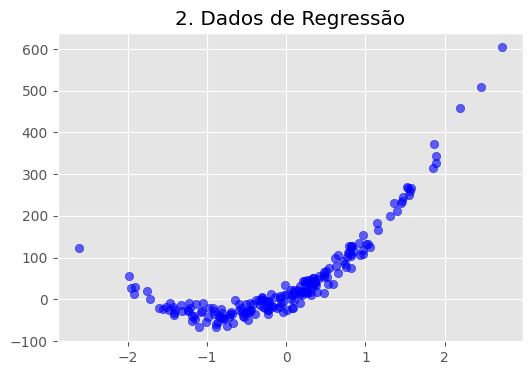

In [24]:
# Gerando dados para Regressão (com um pouco de ruído)
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

# Criando uma leve não-linearidade para testar os modelos depois
y_reg = y_reg + (X_reg[:, 0] ** 2) * 50

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X_reg, y_reg, color='blue', alpha=0.6)
plt.title("2. Dados de Regressão")
plt.show()

Regressão Linear
- Traça a melhor linha reta que minimiza a distância (erro) entre os dados e a própria linha.

In [25]:
from sklearn.linear_model import LinearRegression

# Inicializando e treinando
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)

# Avaliando
mse_lin_reg = mean_squared_error(y_test_r, lin_reg.predict(X_test_r))
print(f"6. Erro Quadrático Médio (MSE) da Regressão Linear: {mse_lin_reg:.2f}")

6. Erro Quadrático Médio (MSE) da Regressão Linear: 6022.44


Support Vector Regression
- Adaptação das Máquinas de Vetores de Suporte (SVM) para regressão. Ela tenta encaixar o maior número de instâncias dentro de uma "rua" (margem) de tamanho epsilon.

7. Erro Quadrático Médio (MSE) do SVR: 412.97


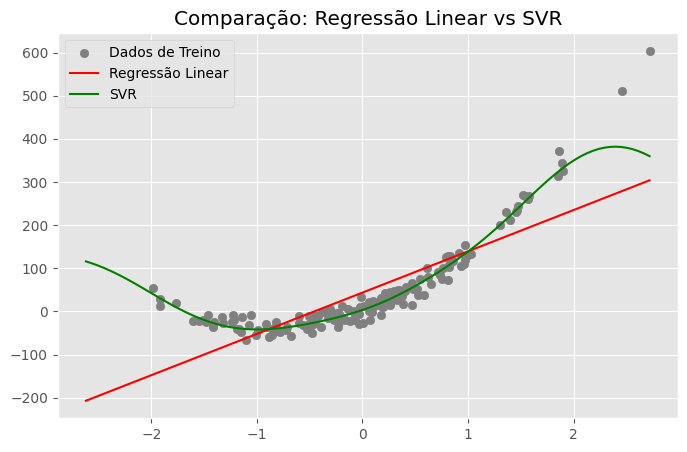

In [26]:
from sklearn.svm import SVR

# Inicializando e treinando com kernel RBF (ajuda a pegar curvas não-lineares)
svr_reg = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_reg.fit(X_train_r, y_train_r)

# Avaliando
mse_svr = mean_squared_error(y_test_r, svr_reg.predict(X_test_r))
print(f"7. Erro Quadrático Médio (MSE) do SVR: {mse_svr:.2f}")

# Visualizando Linear vs SVR
X_plot = np.linspace(X_reg.min(), X_reg.max(), 100).reshape(-1, 1)
plt.figure(figsize=(8, 5))
plt.scatter(X_train_r, y_train_r, color='gray', label='Dados de Treino')
plt.plot(X_plot, lin_reg.predict(X_plot), color='red', label='Regressão Linear')
plt.plot(X_plot, svr_reg.predict(X_plot), color='green', label='SVR')
plt.title("Comparação: Regressão Linear vs SVR")
plt.legend()
plt.show()

Algoritmos de Clusterização
- A clusterização (ou agrupamento) é uma tarefa não supervisionada. O objetivo é agrupar dados semelhantes sem ter nenhum rótulo prévio como "gabarito". Para mostrar a variedade, usaremos o DBSCAN como um exemplo da categoria, antes de ir para o K-Means.

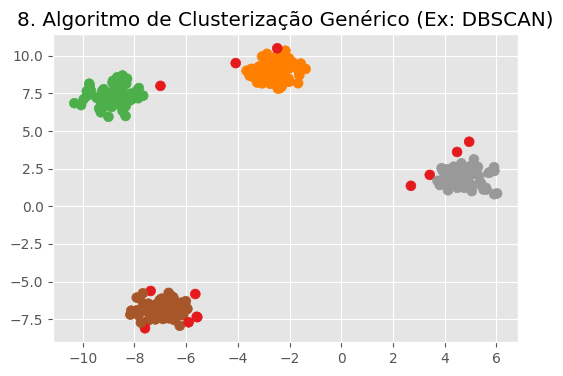

In [27]:
from sklearn.cluster import DBSCAN

# Gerando dados aglomerados
X_clus, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)

# Exemplo de Algoritmo de Clusterização: DBSCAN (Baseado em densidade)
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_clus)

plt.figure(figsize=(6, 4))
plt.scatter(X_clus[:, 0], X_clus[:, 1], c=y_dbscan, cmap='Set1', s=50)
plt.title("8. Algoritmo de Clusterização Genérico (Ex: DBSCAN)")
plt.show()

Algoritmo K-Means
- O K-Means é o algoritmo de clusterização mais famoso. Ele tenta separar os dados em K grupos de variância igual, minimizando a distância entre os pontos de dados e o centroide (centro) do cluster.

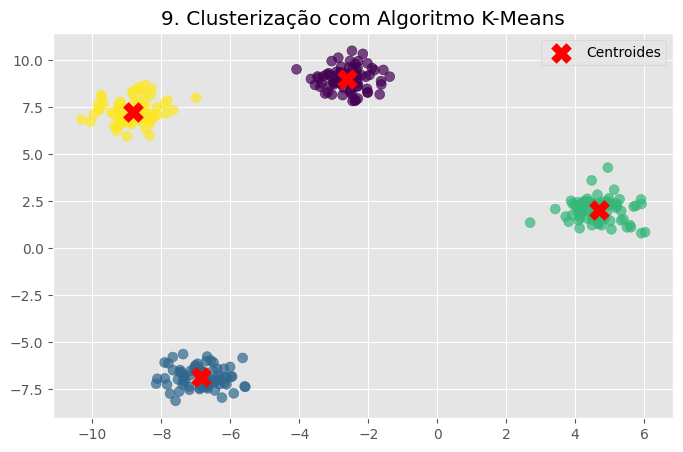

In [28]:
from sklearn.cluster import KMeans

# Inicializando o K-Means para encontrar 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_clus)

# Coordenadas dos centros encontrados
centros = kmeans.cluster_centers_

plt.figure(figsize=(8, 5))
plt.scatter(X_clus[:, 0], X_clus[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centros[:, 0], centros[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title("9. Clusterização com Algoritmo K-Means")
plt.legend()
plt.show()